## Python Replay Notebook

This notebook replays historical candles one bar at a time using the same VWAP probability band engine used by the live workflow.

It is not connected to TradingView. TradingView replay will require a separate Pine Script overlay later.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("✅ Project root added to Python path:")
print(PROJECT_ROOT)

✅ Project root added to Python path:
c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine


In [2]:
from src.config import CONFIG
from src.loaders import load_tradingview_csv, assign_sessions
from src.engine import EngineState, update_engine_state
from src.replay import run_replay

### Load historical data

This loads the configured historical candle file and assigns session ids before replay.

In [ ]:
USE_ONE_YEAR_DATA = True

if USE_ONE_YEAR_DATA:
    csv_path = PROJECT_ROOT / "data" / "historical" / "US100_cash_M1_NY_session_1y.csv"
else:
    csv_path = CONFIG["data_dir"] / CONFIG["csv_filename"]

    if not csv_path.is_absolute():
        csv_path = PROJECT_ROOT / csv_path

print("CSV path:", csv_path)
print("Exists:", csv_path.exists())

df = load_tradingview_csv(csv_path)
df = assign_sessions(df, CONFIG["sessions"])

print("Rows:", len(df))
display(df.head())
display(df.tail())

CSV path: C:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\data\historical\US100_cash_M1_NY_session_30d.csv
Exists: True
✅ TradingView CSV loaded: 6,728 bars from C:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\data\historical\US100_cash_M1_NY_session_30d.csv
Rows: 6728


,datetime,open,high,low,close,tick_volume,typical_price,session_date,session_id,session_name
0,2026-01-29 15:22:00+00:00,26033.45,26035.15,26027.95,26034.55,261,26032.550000,2026-01-29,2026-01-29_NewYork,NewYork
1,2026-01-29 15:23:00+00:00,26034.45,26037.55,26032.15,26034.25,234,26034.650000,2026-01-29,2026-01-29_NewYork,NewYork
2,2026-01-29 15:24:00+00:00,26034.45,26040.05,26034.45,26040.05,234,26038.183333,2026-01-29,2026-01-29_NewYork,NewYork
3,2026-01-29 15:25:00+00:00,26040.15,26044.45,26036.25,26044.25,277,26041.650000,2026-01-29,2026-01-29_NewYork,NewYork
4,2026-01-29 15:26:00+00:00,26044.55,26046.65,26039.25,26045.25,228,26043.716667,2026-01-29,2026-01-29_NewYork,NewYork


,datetime,open,high,low,close,tick_volume,typical_price,session_date,session_id,session_name
6723,2026-03-17 16:25:00+00:00,24785.45,24794.45,24781.55,24792.35,398,24789.450000,2026-03-17,2026-03-17_NewYork,NewYork
6724,2026-03-17 16:26:00+00:00,24792.25,24792.55,24779.95,24782.25,342,24784.916667,2026-03-17,2026-03-17_NewYork,NewYork
6725,2026-03-17 16:27:00+00:00,24781.95,24783.35,24771.25,24772.75,370,24775.783333,2026-03-17,2026-03-17_NewYork,NewYork
6726,2026-03-17 16:28:00+00:00,24772.55,24775.05,24767.55,24775.05,420,24772.550000,2026-03-17,2026-03-17_NewYork,NewYork
6727,2026-03-17 16:29:00+00:00,24774.85,24782.25,24767.05,24769.75,405,24773.016667,2026-03-17,2026-03-17_NewYork,NewYork


### Load probability tables

The replay engine needs a calibrated probability table. The marginal table is used as a fallback when exact trend/context bins are sparse.

In [4]:
tables_dir = PROJECT_ROOT / "artifacts" / "tables"

prob_table_path = tables_dir / "prob_table_trend.parquet"
marginal_table_path = tables_dir / "prob_table_marginal.parquet"

print("Trend table exists:", prob_table_path.exists(), prob_table_path)
print("Marginal table exists:", marginal_table_path.exists(), marginal_table_path)

prob_table = pd.read_parquet(prob_table_path)

if marginal_table_path.exists():
    marginal_table = pd.read_parquet(marginal_table_path)
else:
    marginal_table = prob_table

print("prob_table:", prob_table.shape)
print("marginal_table:", marginal_table.shape)

display(prob_table.head())

Trend table exists: True c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\artifacts\tables\prob_table_trend.parquet
Marginal table exists: True c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\artifacts\tables\prob_table_marginal.parquet
prob_table: (42, 9)
marginal_table: (21, 8)


,zone,trend_bin,outcome,count,total,prob,ci_lower,ci_upper,confidence
0,Z0,down,MR,0,64,0.0000,0.0000,0.0566,LOW
1,Z0,down,CONT,22,64,0.3438,0.2392,0.4660,LOW
2,Z0,down,NEU,42,64,0.6562,0.5340,0.7608,LOW
3,Z0,flat,MR,66,1256,0.0525,0.0415,0.0663,HIGH
4,Z0,flat,CONT,372,1256,0.2962,0.2716,0.3220,HIGH


### Run replay

This steps through the historical data one candle at a time and stores each `EngineState`.

In [5]:
def update_engine_state_with_marginal(state, bar, config, prob_table):
    return update_engine_state(
        state=state,
        bar=bar,
        config=config,
        prob_table=prob_table,
        marginal_table=marginal_table,
    )


states = []

for state in run_replay(
    df=df,
    config=CONFIG,
    prob_table=prob_table,
    EngineState=EngineState,
    update_engine_state=update_engine_state_with_marginal,
    speed=1e9,
):
    states.append(state)

print("Replay states:", len(states))

Replay states: 6728


### Convert replay states to a DataFrame

The resulting `replay_df` is the main output of this notebook.

In [6]:
rows = []

for s in states:
    bands = s.bands or {}
    context = s.context or {}
    probs = s.probabilities or {}

    rows.append({
        "datetime": s.datetime,
        "close": s.close,
        "reference": s.reference,
        "sigma": s.sigma,

        "band_1p": bands.get("1+"),
        "band_1n": bands.get("1-"),
        "band_2p": bands.get("2+"),
        "band_2n": bands.get("2-"),
        "band_3p": bands.get("3+"),
        "band_3n": bands.get("3-"),

        "z_score": s.z_score,
        "z_velocity": s.z_velocity,
        "zone": s.zone,

        "trend_bin": context.get("trend_bin"),
        "volume_bin": context.get("volume_bin"),
        "time_bin": context.get("time_bin"),
        "z_velocity_bin": context.get("z_velocity_bin"),

        "p_mr": probs.get("MR", {}).get("prob"),
        "p_cont": probs.get("CONT", {}).get("prob"),
        "p_neu": probs.get("NEU", {}).get("prob"),
        "edge_gap": probs.get("edge_gap"),
        "dominant": probs.get("dominant"),
        "actionable": probs.get("actionable"),
        "lookup_tier": probs.get("lookup_tier"),

        "bar_index": s.bar_index,
        "session_bar_count": s.session_bar_count,
    })

replay_df = pd.DataFrame(rows)

print(replay_df.shape)
display(replay_df.tail(20))

(6728, 26)


,datetime,close,reference,sigma,band_1p,band_1n,band_2p,band_2n,band_3p,band_3n,...,z_velocity_bin,p_mr,p_cont,p_neu,edge_gap,dominant,actionable,lookup_tier,bar_index,session_bar_count
6708,2026-03-17 16:10:00+00:00,24735.85,24933.143383,236.457512,25169.600895,24696.685871,25406.058407,24460.228359,25642.515919,24223.770847,...,neutral,0.168,0.3544,0.4777,0.1233,NEU,True,1,6709,6709
6709,2026-03-17 16:11:00+00:00,24739.85,24933.129922,234.679014,25167.808936,24698.450908,25402.487951,24463.771894,25637.166965,24229.092879,...,neutral,0.168,0.3544,0.4777,0.1233,NEU,True,1,6710,6710
6710,2026-03-17 16:12:00+00:00,24737.55,24933.115585,233.054283,25166.169868,24700.061302,25399.224151,24467.007019,25632.278434,24233.952736,...,neutral,0.168,0.3544,0.4777,0.1233,NEU,True,1,6711,6711
6711,2026-03-17 16:13:00+00:00,24733.55,24933.100012,231.645783,25164.745795,24701.454228,25396.391578,24469.808445,25628.037361,24238.162662,...,neutral,0.168,0.3544,0.4777,0.1233,NEU,True,1,6712,6712
6712,2026-03-17 16:14:00+00:00,24744.95,24933.083667,229.858497,25162.942164,24703.225170,25392.800661,24473.366674,25622.659158,24243.508177,...,neutral,0.168,0.3544,0.4777,0.1233,NEU,True,1,6713,6713
6713,2026-03-17 16:15:00+00:00,24743.35,24933.065891,228.198016,25161.263906,24704.867875,25389.461922,24476.669860,25617.659938,24248.471844,...,neutral,0.168,0.3544,0.4777,0.1233,NEU,True,1,6714,6714
6714,2026-03-17 16:16:00+00:00,24744.05,24933.049944,226.574145,25159.624089,24706.475799,25386.198233,24479.901655,25612.772378,24253.327510,...,neutral,0.168,0.3544,0.4777,0.1233,NEU,True,1,6715,6715
6715,2026-03-17 16:17:00+00:00,24750.25,24933.030668,224.780527,25157.811195,24708.250141,25382.591722,24483.469614,25607.372249,24258.689088,...,neutral,0.168,0.3544,0.4777,0.1233,NEU,True,1,6716,6716
6716,2026-03-17 16:18:00+00:00,24758.05,24933.011306,222.771101,25155.782407,24710.240204,25378.553509,24487.469103,25601.324610,24264.698002,...,neutral,0.168,0.3544,0.4777,0.1233,NEU,True,1,6717,6717
6717,2026-03-17 16:19:00+00:00,24767.55,24932.992241,220.503801,25153.496042,24712.488440,25373.999842,24491.984640,25594.503643,24271.480839,...,neutral,0.168,0.3544,0.4777,0.1233,NEU,True,1,6718,6718


### Replay checks

These checks show whether zones, trend bins, and probabilities are updating during replay.

In [7]:
print("Zones:")
display(replay_df["zone"].value_counts(dropna=False))

print("Trend bins:")
display(replay_df["trend_bin"].value_counts(dropna=False))

print("Dominant probabilities:")
display(replay_df["dominant"].value_counts(dropna=False))

print("Actionable:")
display(replay_df["actionable"].value_counts(dropna=False))

display(
    replay_df[
        [
            "datetime",
            "close",
            "reference",
            "sigma",
            "z_score",
            "zone",
            "trend_bin",
            "p_mr",
            "p_cont",
            "p_neu",
            "edge_gap",
            "dominant",
            "actionable",
            "lookup_tier",
        ]
    ].tail(30)
)

Zones:


zone
Z2-    2618
Z1-    2494
Z0      677
Z2+     455
Z1+     434
Z3-      39
Z3+      11
Name: count, dtype: int64

Trend bins:


trend_bin
flat    6728
Name: count, dtype: int64

Dominant probabilities:


dominant
NEU    6728
Name: count, dtype: int64

Actionable:


actionable
True     6294
False     434
Name: count, dtype: int64

,datetime,close,reference,sigma,z_score,zone,trend_bin,p_mr,p_cont,p_neu,edge_gap,dominant,actionable,lookup_tier
6698,2026-03-17 16:00:00+00:00,24711.05,24933.358146,250.665472,-0.886872,Z1-,flat,0.168,0.3544,0.4777,0.1233,NEU,True,1
6699,2026-03-17 16:01:00+00:00,24710.55,24933.331108,249.473463,-0.893005,Z1-,flat,0.168,0.3544,0.4777,0.1233,NEU,True,1
6700,2026-03-17 16:02:00+00:00,24716.95,24933.307189,248.073314,-0.872150,Z1-,flat,0.168,0.3544,0.4777,0.1233,NEU,True,1
6701,2026-03-17 16:03:00+00:00,24713.45,24933.284613,246.867751,-0.890495,Z1-,flat,0.168,0.3544,0.4777,0.1233,NEU,True,1
6702,2026-03-17 16:04:00+00:00,24712.85,24933.264581,245.734570,-0.896962,Z1-,flat,0.168,0.3544,0.4777,0.1233,NEU,True,1
6703,2026-03-17 16:05:00+00:00,24714.35,24933.239859,244.585836,-0.894941,Z1-,flat,0.168,0.3544,0.4777,0.1233,NEU,True,1
6704,2026-03-17 16:06:00+00:00,24726.05,24933.218022,243.020349,-0.852472,Z1-,flat,0.168,0.3544,0.4777,0.1233,NEU,True,1
6705,2026-03-17 16:07:00+00:00,24727.55,24933.196641,241.457363,-0.851689,Z1-,flat,0.168,0.3544,0.4777,0.1233,NEU,True,1
6706,2026-03-17 16:08:00+00:00,24730.55,24933.175477,239.839365,-0.844838,Z1-,flat,0.168,0.3544,0.4777,0.1233,NEU,True,1
6707,2026-03-17 16:09:00+00:00,24734.05,24933.159413,238.150294,-0.836066,Z1-,flat,0.168,0.3544,0.4777,0.1233,NEU,True,1


### Quick replay plot

This plots the most recent bars from the replay output as a quick sanity check.

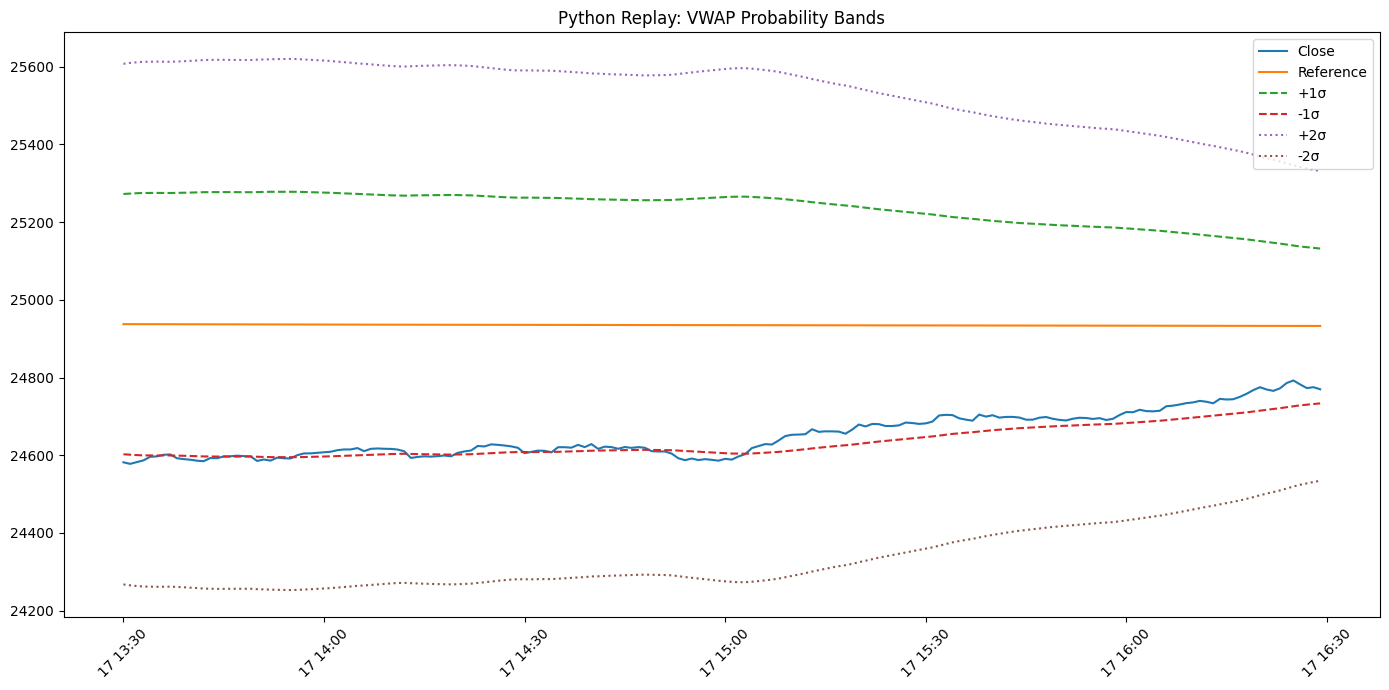

In [8]:
plot_df = replay_df.tail(CONFIG.get("plot_last_n_bars", 180)).copy()

plt.figure(figsize=(14, 7))

plt.plot(plot_df["datetime"], plot_df["close"], label="Close")
plt.plot(plot_df["datetime"], plot_df["reference"], label="Reference")

plt.plot(plot_df["datetime"], plot_df["band_1p"], linestyle="--", label="+1σ")
plt.plot(plot_df["datetime"], plot_df["band_1n"], linestyle="--", label="-1σ")

plt.plot(plot_df["datetime"], plot_df["band_2p"], linestyle=":", label="+2σ")
plt.plot(plot_df["datetime"], plot_df["band_2n"], linestyle=":", label="-2σ")

plt.title("Python Replay: VWAP Probability Bands")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Save replay output

The replay output is saved locally for inspection. It should usually not be committed to Git.

In [9]:
output_path = tables_dir / "replay_output.parquet"
replay_df.to_parquet(output_path, index=False)

print("Saved:", output_path)

Saved: c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\artifacts\tables\replay_output.parquet
